In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
dataset = load_dataset(
    "PolyAI/banking77",
    trust_remote_code=True
)

df = dataset["train"].to_pandas()

df.head()

Using the latest cached version of the module from C:\Users\ankit\.cache\huggingface\modules\datasets_modules\datasets\PolyAI--banking77\17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9 (last modified on Mon Jul  6 21:44:42 2026) since it couldn't be found locally at PolyAI/banking77, or remotely on the Hugging Face Hub.


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10003 non-null  str  
 1   label   10003 non-null  int64
dtypes: int64(1), str(1)
memory usage: 737.5 KB


In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
df.duplicated(subset=["text"]).sum()

np.int64(0)

In [6]:
len(dataset["train"].features["label"].names)

77

In [7]:
label_names = dataset["train"].features["label"].names

df["intent"] = df["label"].apply(lambda x: label_names[x])

df.head()

,text,label,intent
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [8]:
intent_counts = df["intent"].value_counts()

intent_counts

intent
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

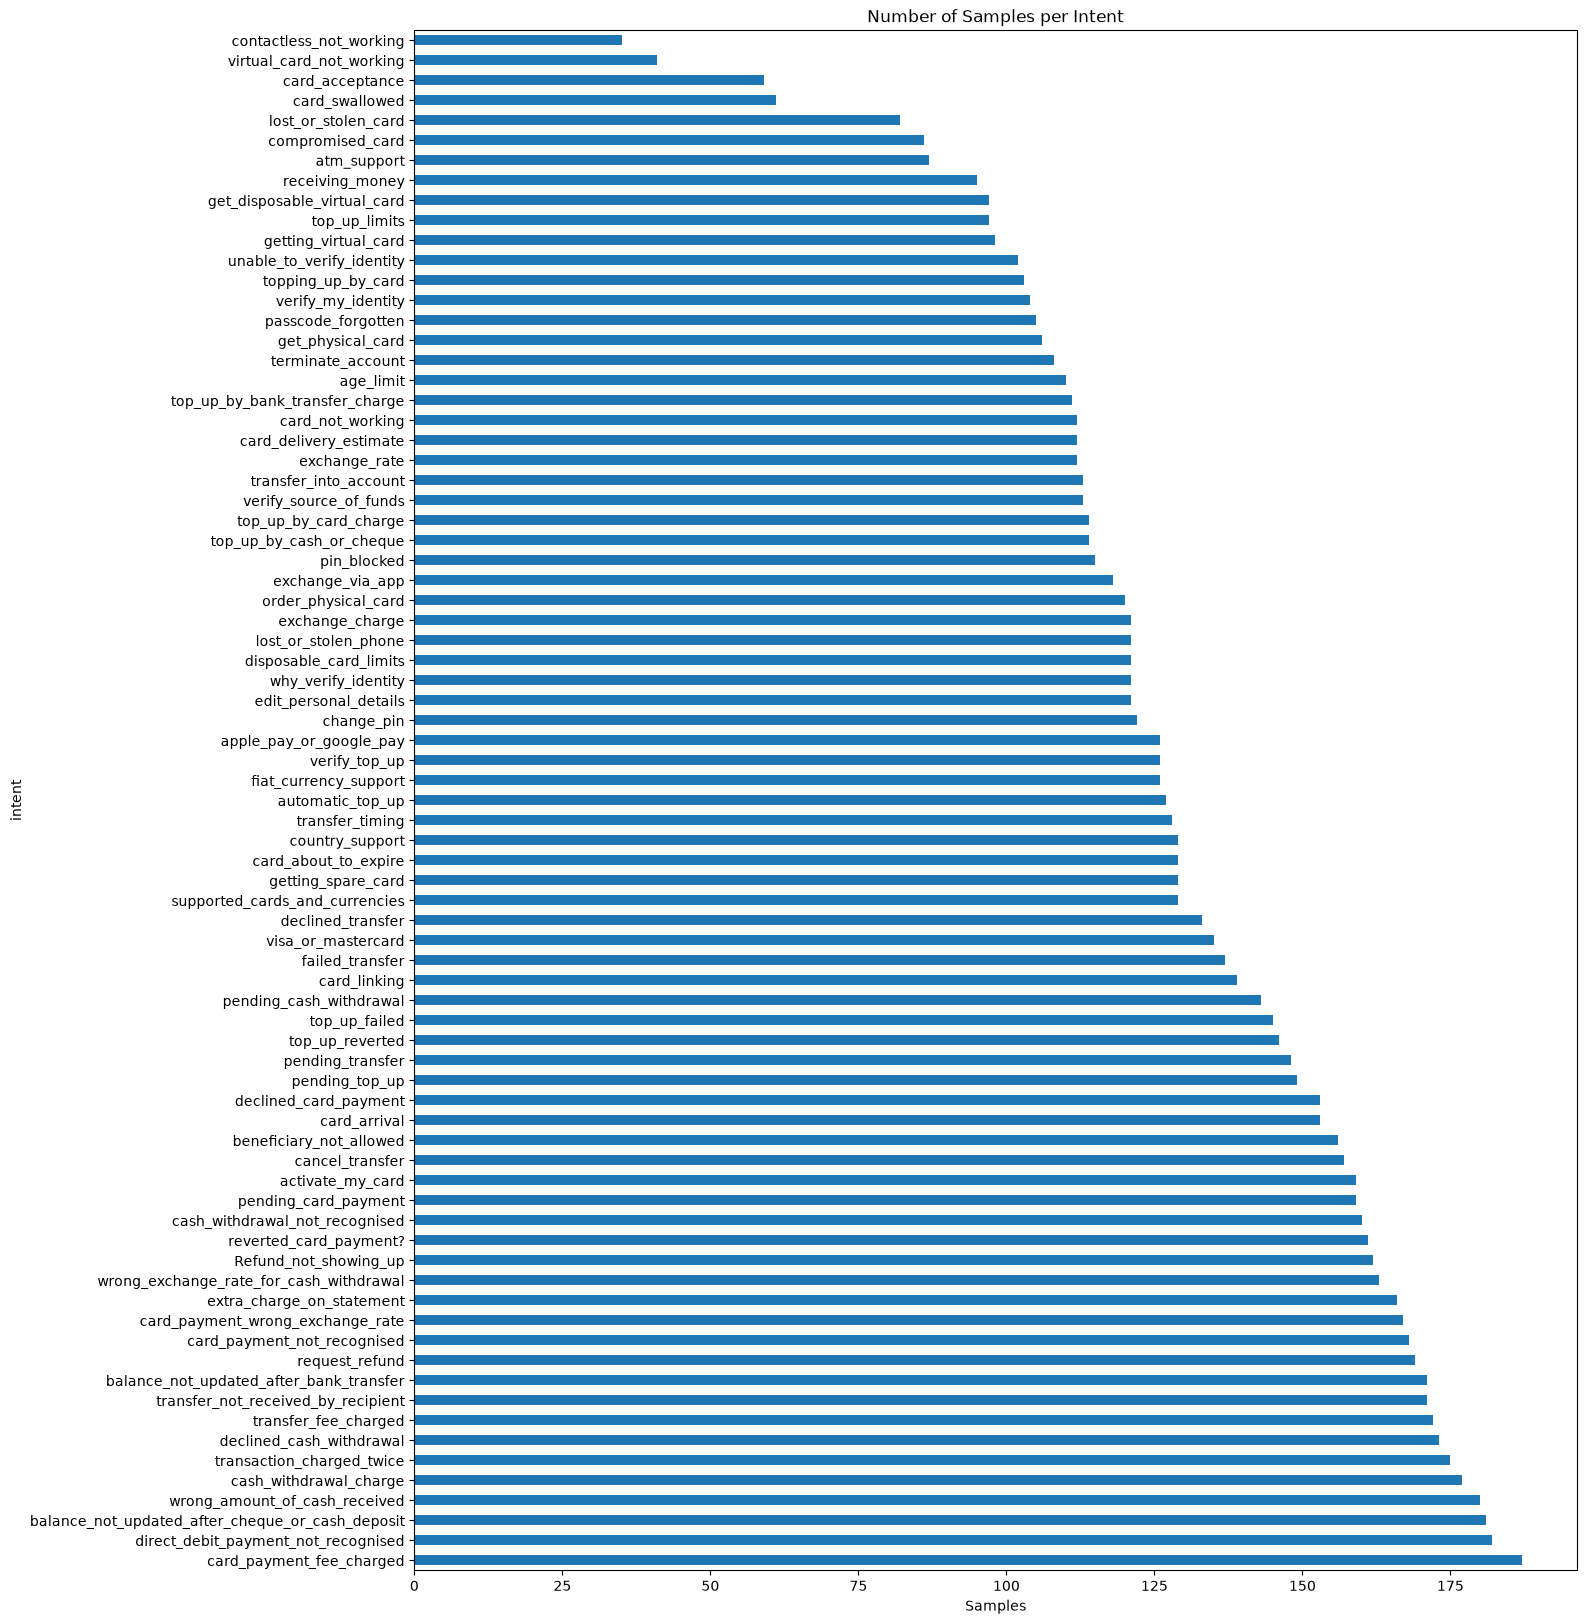

In [9]:
plt.figure(figsize=(15,20))

intent_counts.plot(kind="barh")

plt.title("Number of Samples per Intent")

plt.xlabel("Samples")

plt.show()

In [10]:
df["num_words"] = df["text"].apply(lambda x: len(x.split()))

df[["text", "num_words"]].head()

,text,num_words
0,I am still waiting on my card?,7
1,What can I do if my card still hasn't arrived ...,13
2,I have been waiting over a week. Is the card s...,12
3,Can I track my card while it is in the process...,13
4,"How do I know if I will get my card, or if it ...",15


In [11]:
df["num_words"].describe()

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: num_words, dtype: float64

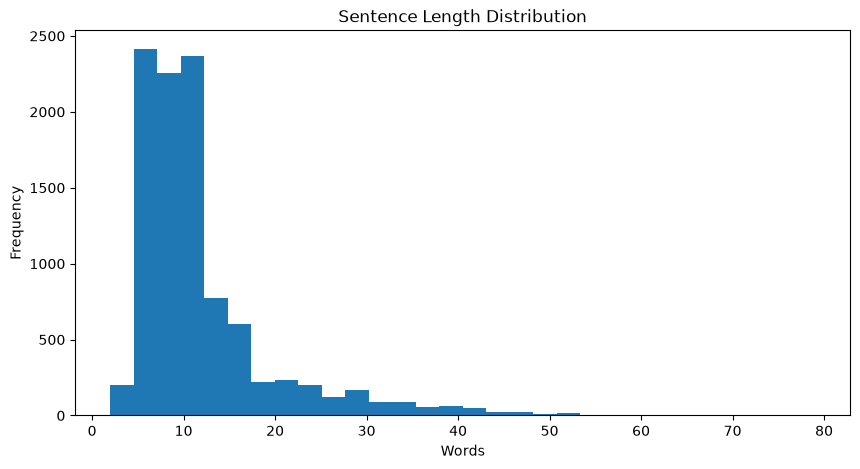

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df["num_words"], bins=30)

plt.title("Sentence Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [13]:
label_names = dataset["train"].features["label"].names

df = dataset["train"].to_pandas()
df["intent"] = df["label"].apply(lambda x: label_names[x])

df[df["text"].str.contains("lost", case=False)][["text", "intent"]].head(20)

,text,intent
4,"How do I know if I will get my card, or if it ...",card_arrival
11,I still haven't received my card after two wee...,card_arrival
32,Has my card been lost in delivery?,card_arrival
38,I haven't received my card and am worried it i...,card_arrival
46,Is my card lost? I am still waiting for it to ...,card_arrival
157,"lost card found, want to put it back in app",card_linking
160,If I find a card I lost do I need to dispose o...,card_linking
170,I found my lost card in my jacket pocket this ...,card_linking
173,"I would like to re-activate my card, it was pr...",card_linking
180,The card I thought was lost was just in my jac...,card_linking


In [14]:
df[df["text"].str.contains("debit", case=False)][["text", "intent"]].head(20)

,text,intent
644,What is this fee debit on my account?,extra_charge_on_statement
2607,Why is there a charged fee for debit or credit...,card_payment_fee_charged
2618,Why am I charged a fee when using my debit or ...,card_payment_fee_charged
2669,Why was I charged a fee for debit or credit ca...,card_payment_fee_charged
2827,|I moved out of my old house two weeks ago and...,transfer_not_received_by_recipient
2925,Can I top off with a debit card?,supported_cards_and_currencies
3109,Where do I pay with my debit or credit card?,card_acceptance
4634,Please help my find out why there is an odd di...,direct_debit_payment_not_recognised
4635,I am seeing in the App a diret debit that its ...,direct_debit_payment_not_recognised
4636,There is a direct debit payment that I did not...,direct_debit_payment_not_recognised


In [15]:
df[df["text"].str.contains("stolen", case=False)][["text", "intent"]].head(20)

,text,intent
216,"I have found my lost or stolen card, would I s...",card_linking
245,If my card was lost or stolen can I re-link it?,card_linking
1478,I need to report a stolen card,lost_or_stolen_card
1479,How do I replace a stolen card?,lost_or_stolen_card
1486,I think that my card has been stolen!,lost_or_stolen_card
1487,My card was stolen,lost_or_stolen_card
1488,A fee shouldn't apply to me if my card was sto...,lost_or_stolen_card
1489,My card has been stolen. I reported it with th...,lost_or_stolen_card
1491,My card has been stolen what do I do?,lost_or_stolen_card
1494,I believe that my card has been stolen!,lost_or_stolen_card


In [16]:
df[df["text"].str.contains("card", case=False)][["text", "intent"]].sample(20, random_state=42)

,text,intent
8440,Can you tell me what the disposable cards are ...,get_disposable_virtual_card
2965,how can i add money from my amex card,supported_cards_and_currencies
6729,Can you tell me why the card payment came back?,reverted_card_payment?
1034,"Give me my card, I need it now!",card_delivery_estimate
7763,Please tell me how to verify my top up card.,verify_top_up
4264,Can i top up by card?,topping_up_by_card
1323,Did you deactivate my card it's not working an...,card_not_working
196,Will I need a new card or can I put my old car...,card_linking
2607,Why is there a charged fee for debit or credit...,card_payment_fee_charged
1298,My card doesn't seem to work anymore,card_not_working


In [17]:
df[df["intent"].str.contains("cash|card", case=False)][["text", "intent"]].sample(30, random_state=42)

,text,intent
3146,Can I pay with my card anywhere?,card_acceptance
23,My card isn't here yet.,card_arrival
252,Is it possible to link a new card?,card_linking
5156,I am waiting for a payment to be processed,pending_card_payment
9069,Which US cards have top up charges?,top_up_by_card_charge
8184,How do I get this damn virtual card to work?,virtual_card_not_working
2540,I got charged a service fee on my account. Can...,card_payment_fee_charged
2960,Help me use American Express to add money to t...,supported_cards_and_currencies
5157,I don't understand why my card payment is pend...,pending_card_payment
3600,There is a payment with my card which i defini...,card_payment_not_recognised
